In [ ]:
from pydantic import BaseModel, Field

from qdrant_client import QdrantClient
from qdrant_client.models import Prefetch, Filter, FieldCondition, MatchText, FusionQuery, Document

from langsmith import traceable, get_current_run_tree

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send, Command

from langchain_core.messages import AIMessage, ToolMessage

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List, Optional, Sequence
from IPython.display import Image, display
from operator import add
from openai import OpenAI

import anthropic

import random
import ast
import inspect
import instructor
import json

from utils.utils import get_tool_descriptions, make_message_langchain_compatible
from dotenv import load_dotenv
import os
import voyageai

/Users/pranjal/Desktop/projects/AI/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
load_dotenv()
VOYAGE_API_KEY = os.environ.get("VOYAGE_API_KEY")
voyageai_client = voyageai.Client(api_key=VOYAGE_API_KEY)
qdrant_client = QdrantClient(url="http://localhost:6333")

# Query Expansion (Parallel Execution)

In [38]:
class  State(BaseModel):
        expanded_query: List[str] = []
        retrieved_context: Annotated[List[str], add] = []
        question_relevant: bool = False
        initial_query: str = ""
        answer: str = ""
        query: str = ""
        k: int = 10

class QueryExpandResponse(BaseModel):
        expanded_query: List[str]


### Query Expansion Node

In [39]:
@traceable(
        name="agent_node_parallel",
        run_type="llm",
        metadata={"ls_provider": "anthropic", "ls_model_name": "claude-haiku-4-5-20251001"},
)
def query_expand_node(state: State) -> dict:
        system_prompt = """
                You are part of a shopping assistant that can answer questions about products in stock.

                Instructions:
                - You will be given a question and you need to expand it into a list of statements that can be used in contextual search to retrieve relevant products.
                - The statements should not overlap in context.
        """

        instructor_client = instructor.from_anthropic(anthropic.Anthropic())

        response, raw_response = instructor_client.messages.create_with_completion(
                model="claude-haiku-4-5-20251001",
                response_model=QueryExpandResponse,
                max_tokens=8096,
                system=system_prompt,
                messages=[
                        {"role": "user", "content": state.initial_query}
                ],
                temperature=0.5,
        )

        return {
                "expanded_query": response.expanded_query
        }

### Edge for parallel execution

In [40]:
def query_expand_conditional_edge_for_parallel_execution(state: State):
        send_messages = []
        for query in state.expanded_query:
                send_messages.append(
                        Send(
                                'retriever_node', # which node the broadcast will be done
                                {
                                        'query': query, # local states for this broadcast since these will be parallel
                                        'k':10,
                                }
                        )
                )
        return send_messages


### Retriever Node

In [41]:
@traceable(
        name="embed_query",
        run_type="embedding",
        metadata={"ls_provider": "voyageai", "ls_model_name": "voyage-3"},
)
def get_embedding(text, model='voyage-3', input_type="document"):
        result = voyageai_client.embed(
                [text],
                model=model,
                input_type=input_type
        )
        return result.embeddings[0]


@traceable(
        name="retrieve_top_n",
        run_type="retriever",
)
def retrieve_data(query, k=5):
        query_embedding = get_embedding(query)
        qdrant_client = QdrantClient(url="http://localhost:6333")
        results = qdrant_client.query_points(
                collection_name="Amazon-items-collection-01-hybrid-search",
                prefetch=[
                        Prefetch(
                                query=query_embedding,
                                using='voyage-3',
                                limit=10,
                        ),
                        Prefetch(
                                query=Document(
                                        text=query,
                                        model="qdrant/bm25"
                                ),
                                using='bm25',
                                limit=10,
                        ),
                ],
                query=FusionQuery(fusion='rrf'), #reciprocal rank fusion
                limit=k,
        )

        retrieved_context_ids = []
        retrieved_context = []
        similarity_scores = []
        retrieved_context_ratings = []

        for item in results.points:
                retrieved_context_ids.append(item.payload['parent_asin'])
                retrieved_context.append(item.payload['description'])
                retrieved_context_ratings.append(item.payload['average_rating'])
                similarity_scores.append(item.score)

        formatted_context = ""
        for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
                formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"
        
        return formatted_context


@traceable(
        name="retriever_node",
        run_type="retriever",
        metadata={"ls_provider": "anthropic", "ls_model_name": "claude-haiku-4-5-20251001"},
)
def retrieve_node(state: State) -> dict:
        retrieved_context = retrieve_data(state['query'], state['k'])
        return {
                "retrieved_context": [retrieved_context]
        }

### Aggregator Node

In [42]:
class AggregatorResponse(BaseModel):
        answer: str = Field(description="Answer to the query")

@traceable(
        name="query_expand_node",
        run_type="llm",
        metadata={"ls_provider": "anthropic", "ls_model_name": "claude-haiku-4-5-20251001"},
)
def aggregator_node(state: State) -> dict:
        prompt_template = """
                You are a shopping assistant that can answer questions about the products in stock.
                You will be given a question and a list of context.

                Instructions:
                - You need to answer the question based on the provided context only.
                - Never use word context and refer to it as the available products.
                - The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

                Context:
                {{ preprocessed_context }}

                Question:
                {{ question }}
        """

        template = Template(prompt_template)
        prompt = template.render(
                preprocessed_context = '\n'.join(state.retrieved_context),
                question = state.initial_query,
        )

        instructor_client = instructor.from_anthropic(anthropic.Anthropic())
        response, raw_response = instructor_client.messages.create_with_completion(
                model="claude-haiku-4-5-20251001",
                response_model=AggregatorResponse,
                max_tokens=8096,
                system=prompt,
                messages=[
                        {"role": "user", "content": "Solve for the requirement"}
                ],
                temperature=0.5,
        )

        return {
                "answer": response.answer
        }

### User Intent Router

In [43]:
class IntentRouterResponse(BaseModel):
        question_relevant: bool
        answer: str

In [44]:
@traceable(
        name="user_intent_router",
        run_type="llm",
        metadata={"ls_provider": "anthropic", "ls_model_name": "claude-haiku-4-5-20251001"},
)
def intent_router_node(state: State):

        prompt_template = """
                You are part of a shopping assistant that can answer questions about products in stock.

                Instructions:
                - You will be given a question and you need to clasify it into relevant or not relevant.
                - If the question is not relevant, return False in field "question_relevant" and set "answer" to explanation why it is not relevant.
                - If the question is relevant, return True in field "question_relevant" and set "answer" to "".
                - You should only answer questions about the products in stock. If the question is not about the products in stock, you should ask for clarification.

                <Question>
                {{ query }}
                </Question>
        """

        template = Template(prompt_template)

        prompt = template.render(
                query=state.initial_query
        )

        instructor_client = instructor.from_anthropic(anthropic.Anthropic())

        response, raw_response = instructor_client.messages.create_with_completion(
                model="claude-haiku-4-5-20251001",
                response_model=IntentRouterResponse,
                max_tokens=8096,
                system=prompt,
                messages=[
                        {"role": "user", "content": "Solve for the requirement"}
                ],
                temperature=0.5,
        )

        return {
                "question_relevant": response.question_relevant,
                "answer": response.answer
        }

In [45]:
def intent_router_conditional_edge(state: State):
        if state.question_relevant:
                return "query_expand_node"
        else:
                return "end"

### graph

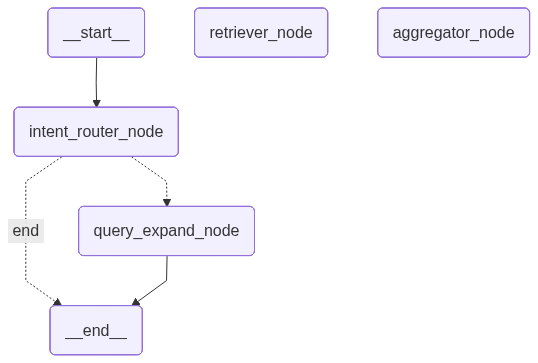

In [46]:
workflow = StateGraph(State)

# Add nodes
workflow.add_node("intent_router_node", intent_router_node)
workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retriever_node", retrieve_node)
workflow.add_node("aggregator_node", aggregator_node)

# Add edges
workflow.add_edge(START, "intent_router_node")
workflow.add_conditional_edges(
        "intent_router_node", 
        intent_router_conditional_edge,
        {
                "query_expand_node": "query_expand_node",
                "end": END
        }
)
workflow.add_conditional_edges(
        "query_expand_node",
        query_expand_conditional_edge_for_parallel_execution
)
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [50]:
initial_state = {
        "initial_query": "Can i get a laptop for me, tablet for my kid, phone for my wife and a speaker for my parents",
}
result = graph.invoke(initial_state)
print(result['answer'])

Based on the available products, I can help you find suitable items for your family:

## **1. LAPTOP FOR YOU**

**TRUNIUM Laptop Stand** (ID: B0BWD5TKNH) - Rating: 4.6/5
- **Multi-Angle Adjustable Stand** with heat-vent design
- **Wide Compatibility**: Supports laptops from 10-15.6 inches including MacBook Pro/Air, Surface Laptop, Dell XPS, HP, Acer, Chromebook
- **Key Features**:
  - Ergonomic design elevates screen to eye level
  - Relieves neck, shoulder, and spinal pain
  - Made of high-quality aluminum alloy
  - 4 slide-proof silicone pads for stability
  - Hollow surface design for heat dissipation
  - Protective hooks prevent laptop from sliding
  - Premium texture, resistant to dirt and fingerprints

**Alternative Option**: ZKSIND Adjustable Laptop Stand (ID: B0B87XZT6M) - Rating: 4.5/5
- 360° rotating base for collaborative work
- Fully foldable for easy storage
- Fits laptops up to 16 inches

---

## **2. TABLET FOR YOUR KID**

**G-TiDE Kids Tablet** (ID: B0B157WDDJ) - Rating

In [51]:
initial_state = {
        "initial_query": "what is weather like today?",
}
result = graph.invoke(initial_state)
print(result['answer'])

This question is not relevant to our shopping assistant. We can only answer questions about products in stock. The question "what is weather like today?" is about weather conditions, not about products. Please ask me about products you're interested in, and I'll be happy to help!
